In [ ]:
# user distribution per post volume
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dem_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_democrats_clean.csv'
rep_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_republicans_clean.csv'

cols_to_use = ['author_name']

dem_df = pd.read_csv(dem_path, usecols=cols_to_use)
dem_df['party'] = 'Democrat'

rep_df = pd.read_csv(rep_path, usecols=cols_to_use)
rep_df['party'] = 'Republican'

df = pd.concat([dem_df, rep_df], ignore_index=True)

print("\n post counts per user")
user_counts = df.groupby(['party', 'author_name']).size().reset_index(name='post_count')

active_users = user_counts[user_counts['post_count'] >= 5].copy()

print(f"Total Unique Users: {len(user_counts):,}")
print(f"Active Users (>= 5 posts): {len(active_users):,}")
print(f"User Retention Rate: {(len(active_users)/len(user_counts))*100:.2f}%")

plt.figure(figsize=(12, 6))

sns.histplot(
    data=active_users, 
    x='post_count', 
    hue='party', 
    log_scale=(True, True),
    element='step', 
    fill=False, 
    linewidth=2,
    common_norm=False
)

plt.title('Distribution of Post Volume per User (Log-Log Scale)\n(Users with >= 5 posts)', fontsize=14)
plt.xlabel('Number of Posts (Log Scale)', fontsize=12)
plt.ylabel('Number of Users (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(title='Party', labels=['Republican', 'Democrat'])

plt.show()'''


'\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\ndem_path = \'/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_democrats_clean.csv\'\nrep_path = \'/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_republicans_clean.csv\'\n\ncols_to_use = [\'author_name\']\n\ndem_df = pd.read_csv(dem_path, usecols=cols_to_use)\ndem_df[\'party\'] = \'Democrat\'\n\nrep_df = pd.read_csv(rep_path, usecols=cols_to_use)\nrep_df[\'party\'] = \'Republican\'\n\ndf = pd.concat([dem_df, rep_df], ignore_index=True)\n\nprint("\n post counts per user")\nuser_counts = df.groupby([\'party\', \'author_name\']).size().reset_index(name=\'post_count\')\n\nactive_users = user_counts[user_counts[\'post_count\'] >= 5].copy()\n\nprint(f"Total Unique Users: {len(user_counts):,}")\nprint(f"Active Users (>= 5 posts): {len(active_users):,}")\nprint(f"User Retention Rate: {(len(active_users)/len(user_counts))*100:.2f}%")\n\nplt.figure(figsize=(12, 6))\n\nsns.histplot(\n    data=active_users, \n  

In [2]:
# reload the data

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

dem_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_democrats_clean.csv'
rep_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/reddit_republicans_clean.csv'

dem_df = pd.read_csv(dem_path)
rep_df = pd.read_csv(rep_path)

dem_df['party_label'] = 'Democrat'
rep_df['party_label'] = 'Republican'

full_df = pd.concat([dem_df, rep_df], ignore_index=True)

/Users/kimminseo/Documents/UCPH/ISP/pycode/ispenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/tq/pmn07sd93gs_hl4cdhsww3qh0000gn/T/ipykernel_60154/325886495.py:11: DtypeWarning: Columns (8,9,10,16,17,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dem_df = pd.read_csv(dem_path)
/var/folders/tq/pmn07sd93gs_hl4cdhsww3qh0000gn/T/ipykernel_60154/325886495.py:12: DtypeWarning: Columns (8,9,10,17,21) have mixed types. Specify dtype option on import or set low_memory=False.
  rep_df = pd.read_csv(rep_path)


In [35]:
author_counts = full_df['author_name'].value_counts()

# superusers with 500+ posts
superusers_list = author_counts[(author_counts >= 500) & (author_counts.index != '[deleted]')].index

print(f"Found {len(superusers_list)} unique superusers.")

superuser_df = full_df[full_df['author_name'].isin(superusers_list)].copy()

superuser_df = superuser_df.sort_values(by=['author_name', 'created_time'])

print(f"Superuser DataFrame size: {len(superuser_df)} rows")

Found 2495 unique superusers.
Superuser DataFrame size: 2374293 rows


In [38]:
# calculating sampling fraction

import time

model = SentenceTransformer('all-mpnet-base-v2')
# model = SentenceTransformer('all-MiniLM-L6-v2') <- too light

TARGET_HOURS = 3.0
SAFETY_MARGIN = 0.95  # Keep 5% buffer
TEXT_COL = 'self_text'
USER_ID_COL = 'author_name'

print(f"Total superuser posts before sampling: {len(superuser_df):,}")

# Benchmark Model Speed

benchmark_sample = superuser_df[TEXT_COL].astype(str).iloc[:50].tolist()

start_time = time.time()
_ = model.encode(benchmark_sample, show_progress_bar=False)
end_time = time.time()

avg_sec_per_post = (end_time - start_time) / 50
print(f"Average processing time: {avg_sec_per_post:.4f} seconds/post")

# B. Calculate Safe Capacity
total_seconds_available = (TARGET_HOURS * 3600) * SAFETY_MARGIN
max_posts_capacity = int(total_seconds_available / avg_sec_per_post)

total_posts = len(superuser_df)
calculated_fraction = max_posts_capacity / total_posts
safe_fraction = min(calculated_fraction, 1.0)

print(f"Time Budget: {TARGET_HOURS} hours")
print(f"Max Capacity: {max_posts_capacity:,} posts")
print(f"Sampling Rate: {safe_fraction:.2%}")

Total superuser posts before sampling: 355,018
Average processing time: 0.0331 seconds/post
Time Budget: 3.0 hours
Max Capacity: 309,969 posts
Sampling Rate: 87.31%


In [39]:
# applying sampling

if safe_fraction < 1.0:
    print(f"\nDownsampling to fit time limit (Rate: {safe_fraction:.2%})...")
    
    try:
        sampled_df = superuser_df.groupby(USER_ID_COL, group_keys=False).sample(frac=safe_fraction, random_state=42)
    except AttributeError:
        sampled_df = superuser_df.groupby(USER_ID_COL, group_keys=False).apply(
            lambda x: x.sample(frac=safe_fraction, random_state=42)
        )
    
    print(f"Final size: {len(sampled_df):,}")
    
    superuser_df = sampled_df.copy()
else:
    print("\nhandle 100% of the posts")


Downsampling to fit time limit (Rate: 87.31%)...
Final size: 309,956


In [40]:
# Generate Embeddings

print(f"\nGenerating MPNet embeddings for {len(superuser_df):,} posts...")

embeddings = model.encode(superuser_df['self_text'].tolist(), show_progress_bar=True)
superuser_df['bert_vector'] = list(embeddings)


Generating MPNet embeddings for 309,956 posts...


Batches: 100%|██████████| 9687/9687 [44:16<00:00,  3.65it/s]     


In [41]:
# helper functions

def get_centroid(vectors):
    return np.mean(np.vstack(vectors), axis=0)

def create_axis(positive_vectors, negative_vectors):
    pos_center = get_centroid(positive_vectors)
    neg_center = get_centroid(negative_vectors)
    return pos_center - neg_center

def calculate_score(vector, axis):
    v = vector.reshape(1, -1)
    ax = axis.reshape(1, -1)
    return cosine_similarity(v, ax)[0][0]

In [43]:
# Agressiveness anchor sentences
from sklearn.cluster import KMeans

seed_aggressive = [
    'stupid', 'dumb', 'bullshit', 'racist', 'lying', 'mad', 
    'nonsense', 'ridiculous', 'fraud', 'awful', 'fake', 
    'insane', 'shit', 'terrible', 'worst', 'lies', 'hypocrite'
]
seed_calm = [
    'understand', 'agree', 'civil', 'fair', 'reasonable', 
    'respect', 'reason', 'understanding', 'fine', 'opinion', 
    'sense', 'okay', 'discussion', 'consider'
]

def discover_anchors(df, seeds, n_anchors=10):
    seed_vecs = model.encode(seeds)
    concept_centroid = np.mean(seed_vecs, axis=0).reshape(1, -1)
    
    all_vecs = np.vstack(df['bert_vector'].values)
    sims = cosine_similarity(all_vecs, concept_centroid).flatten()
    
    temp_df = df.copy()
    temp_df['sim_score'] = sims
    candidates = temp_df[
        (temp_df['self_text'].str.len() >= 30) & 
        (temp_df['self_text'].str.len() <= 300)
    ].sort_values('sim_score', ascending=False).head(100)
    
    kmeans = KMeans(n_clusters=n_anchors, random_state=42)
    kmeans.fit(np.vstack(candidates['bert_vector'].values))
    
    discovered = []
    for i in range(n_anchors):
        center = kmeans.cluster_centers_[i].reshape(1, -1)
        dists = cosine_similarity(np.vstack(candidates['bert_vector'].values), center).flatten()
        best_idx = dists.argmax()
        discovered.append(candidates.iloc[best_idx]['self_text'])
        
    return discovered

print("Discovered Anchors")
agg_anchors = discover_anchors(superuser_df, seed_aggressive)
calm_anchors = discover_anchors(superuser_df, seed_calm)

print("\n--- Discovered Aggressive Anchors ---")
for s in agg_anchors:
    print(f"- {s}")

print("\n--- Discovered Calm Anchors ---")
for s in calm_anchors:
    print(f"- {s}")

Discovered Anchors

--- Discovered Aggressive Anchors ---
- Such a vile and repugnant human being.
- What a profound waste of time and energy.
- Fucking ridiculous and pathetic.  Wtf is wrong with this asshole
- What a stupid and strange person.
- What a joke! A skinbag of lies and vitriol.
- Stupid headline about non credible journalist.
- Wow. The stupid is so strong, it hurts.
- Is this fraud in the room with you now?
- This is outrageous and unacceptable
- Get out of here with this load of crap.

--- Discovered Calm Anchors ---
- i think creating the post is soliciting your opinion 😉  and I appreciate it
- This was reasonable, respectful and to the point. Well done.
- Hey! Common sense is not allowed!
- I needed to put into terms the right understands.
- Scroll down the thread a little. Many of us have made clear our opinions on them
- He said enough to not have an opinion for or against
- Fine. Let's continue this non dialog. I am cool with that
- I'm sorry, but I can't respond to

In [44]:
# Agressive Scores

agg_vecs = model.encode(agg_anchors)
calm_vecs = model.encode(calm_anchors)
axis_agg = create_axis(agg_vecs, calm_vecs)

superuser_df['heuristic_agg_score'] = superuser_df['bert_vector'].apply(
    lambda x: calculate_score(x, axis_agg)
)

In [45]:
# Agreesive Training

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


df_sorted = superuser_df.sort_values('heuristic_agg_score')
n_samples = int(len(df_sorted) * 0.10)

train_calm = df_sorted.head(n_samples).copy()
train_agg  = df_sorted.tail(n_samples).copy()

train_calm['label'] = 0
train_agg['label'] = 1

train_data = pd.concat([train_calm, train_agg])
X_train_weak = np.vstack(train_data['bert_vector'].values)
y_train_weak = train_data['label']

X_tr, X_te, y_tr, y_te = train_test_split(X_train_weak, y_train_weak, test_size=0.2, stratify=y_train_weak)
agg_model = LogisticRegression(max_iter=1000, class_weight='balanced')
agg_model.fit(X_tr, y_tr)

print("Aggressiveness Model Accuracy :")
print(classification_report(y_te, agg_model.predict(X_te)))

print("Applying Aggressiveness Model to full dataset...")
agg_model.fit(X_train_weak, y_train_weak)

superuser_df['model_agg_score'] = agg_model.predict_proba(np.vstack(superuser_df['bert_vector'].values))[:, 1]

Aggressiveness Model Accuracy :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6199
           1       1.00      1.00      1.00      6199

    accuracy                           1.00     12398
   macro avg       1.00      1.00      1.00     12398
weighted avg       1.00      1.00      1.00     12398

Applying Aggressiveness Model to full dataset...


In [ ]:
'''# Polarization Scoring

dem_high_sig = dem_df[dem_df['self_text'].str.len() > 50].sample(n=2000, random_state=42)
rep_high_sig = rep_df[rep_df['self_text'].str.len() > 50].sample(n=2000, random_state=42)

dem_ref_vecs = model.encode(dem_high_sig['self_text'].tolist(), show_progress_bar=True)
rep_ref_vecs = model.encode(rep_high_sig['self_text'].tolist(), show_progress_bar=True)

axis_pol = create_axis(rep_ref_vecs, dem_ref_vecs)

print("Calculating Heuristic Polarization Scores...")
superuser_df['heuristic_pol_score'] = superuser_df['bert_vector'].apply(
    lambda x: calculate_score(x, axis_pol)
)
'''

Batches: 100%|██████████| 63/63 [00:19<00:00,  3.31it/s]


Calculating Heuristic Polarization Scores...


In [ ]:
'''# Polarization Training

df_pol_sorted = superuser_df.sort_values('heuristic_pol_score')
n_samples_pol = int(len(df_pol_sorted) * 0.10)

train_dem = df_pol_sorted.head(n_samples_pol).copy()
train_rep = df_pol_sorted.tail(n_samples_pol).copy()

train_dem['pol_label'] = 0
train_rep['pol_label'] = 1

train_data_pol = pd.concat([train_dem, train_rep])
X_train_pol = np.vstack(train_data_pol['bert_vector'].values)
y_train_pol = train_data_pol['pol_label']

pol_model = LogisticRegression(max_iter=1000, class_weight='balanced')
pol_model.fit(X_train_pol, y_train_pol)

print("Applying Polarization Model to full dataset...")
superuser_df['model_pol_score'] = pol_model.predict_proba(np.vstack(superuser_df['bert_vector'].values))[:, 1]'''

Applying Polarization Model to full dataset...


In [ ]:
'''pd.set_option('display.max_colwidth', 150)

print(f"Dataset Size: {len(superuser_df):,} posts")

print("\n--- 1. Random Samples ---")
cols_to_show = ['party_label', 'self_text', 'model_agg_score', 'model_pol_score']

cols_to_show = [c for c in cols_to_show if c in superuser_df.columns]
print(superuser_df[cols_to_show].sample(5))

if 'model_agg_score' in superuser_df.columns:
    print("\n--- Top 5 Most Aggressive ---")
    top_agg = superuser_df.sort_values('model_agg_score', ascending=False).head(5)
    print(top_agg[['model_agg_score', 'self_text']])

    print("\n--- Top 5 Calmest ---")
    top_calm = superuser_df.sort_values('model_agg_score', ascending=True).head(5)
    print(top_calm[['model_agg_score', 'self_text']])

if 'model_pol_score' in superuser_df.columns:
    print("\n--- Top 5 Most Republican ---")
    top_rep = superuser_df.sort_values('model_pol_score', ascending=False).head(5)
    print(top_rep[['model_pol_score', 'party_label', 'self_text']])

    print("\n--- Top 5 Most Democrat ---")
    top_dem = superuser_df.sort_values('model_pol_score', ascending=True).head(5)
    print(top_dem[['model_pol_score', 'party_label', 'self_text']])'''

Dataset Size: 309,956 posts

--- 1. Random Samples ---
        party_label  \
6419036  Republican   
7268650  Republican   
4675636    Democrat   
8480662  Republican   
1043996    Democrat   

                                                                                                                                                     self_text  \
6419036                   Kushner got to make sure that all of that beachfront property in Gaza is still for the taking. He has a lot of money riding on that.   
7268650  &gt;This is a tragedy on every level that was done to "save money" when it was literally less than 1% of the budget and will not accomplish a god ...   
4675636  And he wasn’t just black, dude shared a name with a guy who was Public Enemy No. 2 of the US for a while and his last name rhymed with Public Enem...   
8480662                                                                               -sigh-  \n\n&gt;“So this is how liberty dies. With thunderous applause.”

/var/folders/tq/pmn07sd93gs_hl4cdhsww3qh0000gn/T/ipykernel_60154/438823418.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trends = superuser_df.set_index('created_time').resample('M')[['model_agg_score', 'model_pol_score']].mean()


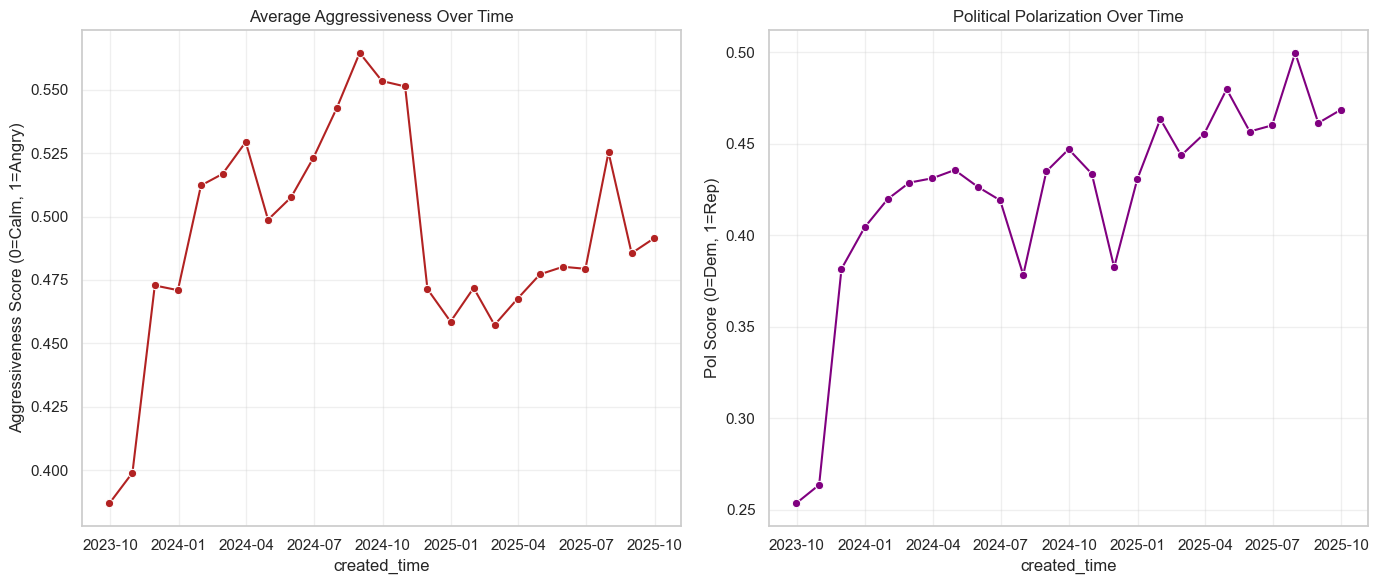

In [ ]:
'''# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

superuser_df['created_time'] = pd.to_datetime(superuser_df['created_time'])

monthly_trends = superuser_df.set_index('created_time').resample('M')[['model_agg_score', 'model_pol_score']].mean()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_trends, x=monthly_trends.index, y='model_agg_score', color='firebrick', marker='o')
plt.title('Average Aggressiveness Over Time')
plt.ylabel('Aggressiveness Score (0=Calm, 1=Angry)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_trends, x=monthly_trends.index, y='model_pol_score', color='purple', marker='o')
plt.title('Political Polarization Over Time')
plt.ylabel('Pol Score (0=Dem, 1=Rep)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()'''

In [50]:
output_path = '/Users/kimminseo/Documents/UCPH/ISP/dataset/superuser_with_scores.csv'

superuser_df.to_csv(output_path, index=False)


Saving full dataset to: /Users/kimminseo/Documents/UCPH/ISP/dataset/superuser_with_scores.csv


#   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   comment_id                  5 non-null      object 
 1   score                       5 non-null      int64  
 2   self_text                   5 non-null      object 
 3   subreddit                   5 non-null      object 
 4   created_time                5 non-null      object 
 5   post_id                     5 non-null      object 
 6   author_name                 5 non-null      object 
 7   controversiality            5 non-null      float64
 8   ups                         5 non-null      int64  
 9   downs                       5 non-null      int64  
 10  user_is_verified            5 non-null      bool   
 11  user_account_created_time   5 non-null      object 
 12  user_awardee_karma          5 non-null      float64
 13  user_awarder_karma          5 non-null      float64
 14  user_link_karma             5 non-null      float64
 15  user_comment_karma          5 non-null      float64
 16  user_total_karma            5 non-null      float64
 17  post_score                  5 non-null      int64  
 18  post_self_text              0 non-null      float64
 19  post_title                  5 non-null      object 
 20  post_upvote_ratio           5 non-null      float64
 21  post_thumbs_ups             5 non-null      int64  
 22  post_total_awards_received  5 non-null      float64
 23  post_created_time           5 non-null      object 
 24  party_label                 5 non-null      object 
 25  bert_vector                 5 non-null      object 
 26  heuristic_agg_score         5 non-null      float64
 27  model_agg_score             5 non-null      float64
 28  heuristic_pol_score         5 non-null      float64
 29  model_pol_score             5 non-null      float64